# Ejercicio 12: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

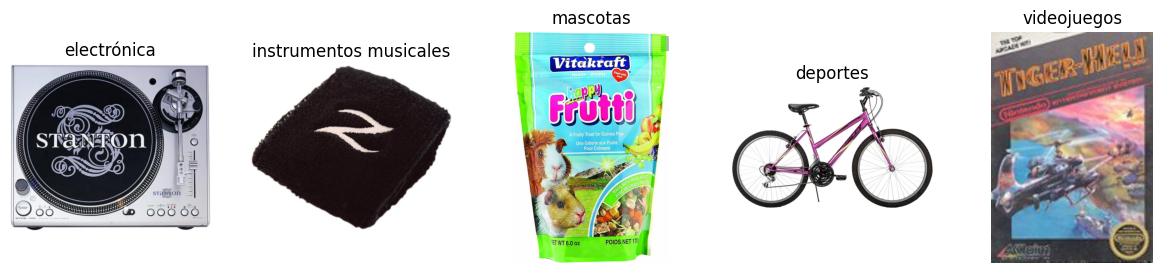

In [5]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA
from transformers import CLIPProcessor, CLIPModel

# 1. Cargar el modelo CLIP pre-entrenado y su procesador
model_id = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_id)
model = CLIPModel.from_pretrained(model_id)

# 2. Cargar imágenes locales desde las categorías
base_dir = r"C:\Users\luis3\Downloads\Multimodal-Information-Retrieval-System\data\raw\images"
categories = ["Electronics", "Musical_Instruments", "Pet_Supplies", "Sports_and_Outdoors", "Video_Games"]
spanish_labels = {
    "Electronics": "electrónica",
    "Musical_Instruments": "instrumentos musicales",
    "Pet_Supplies": "mascotas",
    "Sports_and_Outdoors": "deportes",
    "Video_Games": "videojuegos"
}

images = []
image_labels = []

# Seleccionaremos textos representativos (uno por categoría)
unique_texts = [f"una foto de {spanish_labels[cat]}" for cat in categories]

# Tomar 3 imágenes por categoría (15 en total)
for cat in categories:
    cat_files = glob.glob(os.path.join(base_dir, f"raw_meta_{cat}_*.jpg"))
    selected = cat_files[:3] 
    for file_path in selected:
        images.append(Image.open(file_path).convert('RGB'))
        image_labels.append(spanish_labels[cat])

# Mostrar algunas imágenes de muestra (1 de cada categoría)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    idx = i * 3 # Tomar la primera imagen de cada categoría
    axes[i].imshow(images[idx])
    axes[i].axis("off")
    axes[i].set_title(image_labels[idx])
plt.show()

### Obtención de Embeddings de Textos e Imágenes

A continuación, pasaremos las imágenes y los textos por el modelo CLIP para obtener los *embeddings* (vectores) de cada uno. Luego los normalizaremos, ya que la similitud del coseno sobre vectores normalizados equivale al producto punto, facilitando la comparación y proyección.

In [7]:
# 3. Procesar entradas y obtener embeddings
# Dado que tenemos 15 imágenes y 5 textos, las procesamos por separado 
# para obtener los embeddings usando los atributos seguros 'image_embeds' y 'text_embeds'

# Procesar imágenes (con texto dummy)
inputs_images = processor(images=images, text=[""] * len(images), return_tensors="pt", padding=True)
with torch.no_grad():
    outputs_images = model(**inputs_images)
    image_embeddings = outputs_images.image_embeds

# Procesar textos (con imagen dummy)
inputs_texts = processor(text=unique_texts, images=[images[0]] * len(unique_texts), return_tensors="pt", padding=True)
with torch.no_grad():
    outputs_texts = model(**inputs_texts)
    text_embeddings = outputs_texts.text_embeds

# Normalizar los embeddings para que la norma L2 sea 1
image_embeddings = image_embeddings / image_embeddings.norm(p=2, dim=-1, keepdim=True)
text_embeddings = text_embeddings / text_embeddings.norm(p=2, dim=-1, keepdim=True)

image_embeddings_np = image_embeddings.numpy()
text_embeddings_np = text_embeddings.numpy()

print(f"Dimensión de los embeddings de imágenes: {image_embeddings_np.shape}")
print(f"Dimensión de los embeddings de textos: {text_embeddings_np.shape}")

Dimensión de los embeddings de imágenes: (15, 512)
Dimensión de los embeddings de textos: (5, 512)


### Verificando emparejamientos mediante Similitud del Coseno

Al estar ambos vectores (textos e imágenes) en el mismo espacio vectorial, podemos medir su similitud. CLIP fue entrenado precisamente para maximizar la similitud del coseno entre imágenes y sus textos correspondientes, y minimizarla para los pares incorrectos.

In [8]:
# 4. Mostrar similitud del coseno (promedio por categoría)
print("--- Similitud promedio del coseno ---")
for i, txt in enumerate(unique_texts):
    print(f"\nTexto: '{txt}'")
    for j, cat in enumerate(categories):
        # Promedio de similitud con las 3 imágenes de esta categoría
        sim_sum = 0
        for k in range(3):
            img_idx = j * 3 + k
            sim_sum += (1 - cosine(text_embeddings_np[i], image_embeddings_np[img_idx]))
        avg_sim = sim_sum / 3
        print(f"  vs Imágenes de {spanish_labels[cat]}: {avg_sim:.4f}")

--- Similitud promedio del coseno ---

Texto: 'una foto de electrónica'
  vs Imágenes de electrónica: 0.2056
  vs Imágenes de instrumentos musicales: 0.1628
  vs Imágenes de mascotas: 0.1615
  vs Imágenes de deportes: 0.1615
  vs Imágenes de videojuegos: 0.1554

Texto: 'una foto de instrumentos musicales'
  vs Imágenes de electrónica: 0.1871
  vs Imágenes de instrumentos musicales: 0.2073
  vs Imágenes de mascotas: 0.1606
  vs Imágenes de deportes: 0.1519
  vs Imágenes de videojuegos: 0.1438

Texto: 'una foto de mascotas'
  vs Imágenes de electrónica: 0.1484
  vs Imágenes de instrumentos musicales: 0.1575
  vs Imágenes de mascotas: 0.1947
  vs Imágenes de deportes: 0.1629
  vs Imágenes de videojuegos: 0.1565

Texto: 'una foto de deportes'
  vs Imágenes de electrónica: 0.1675
  vs Imágenes de instrumentos musicales: 0.1695
  vs Imágenes de mascotas: 0.1745
  vs Imágenes de deportes: 0.1788
  vs Imágenes de videojuegos: 0.1650

Texto: 'una foto de videojuegos'
  vs Imágenes de electrónic

### Proyección 2D (PCA) de los Embeddings

Para tener una noción intuitiva de dónde caen los textos y las imágenes, podemos reducir su dimensionalidad (de 512 a 2 dimensiones) usando PCA (Análisis de Componentes Principales) y visualizarlos en el plano 2D. Se espera que el texto del gato esté cerca de la imagen del gato, el texto del perro cerca de la imagen del perro, etc.

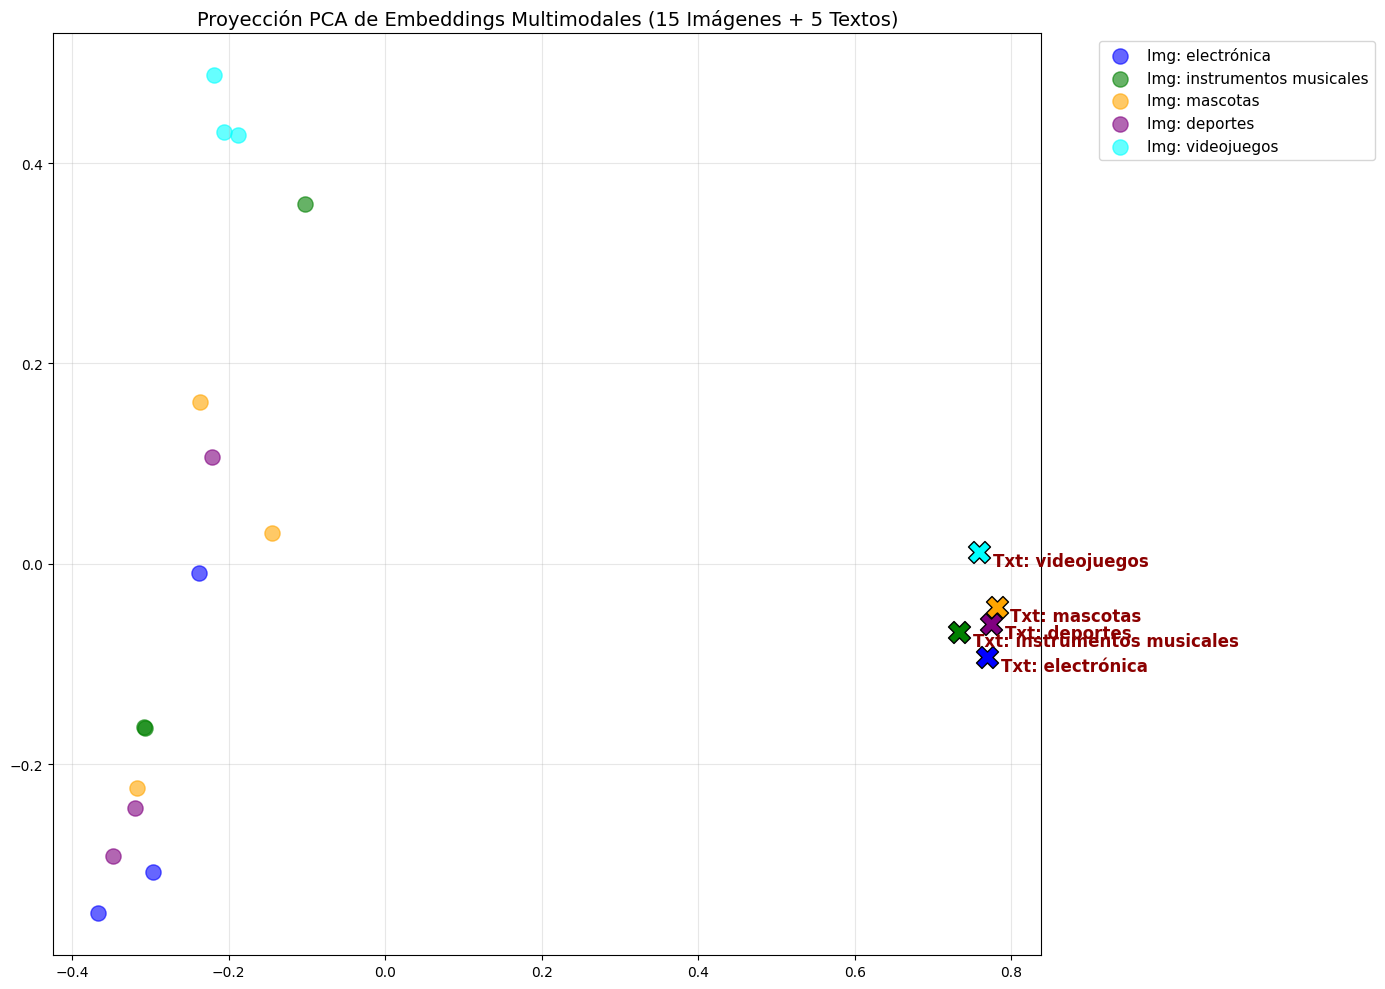

In [9]:
# 5. Proyectar todos los embeddings a 2D usando PCA
# Apilamos verticalmente todos los embeddings (15 imágenes + 5 textos)
all_embeddings = np.vstack([image_embeddings_np, text_embeddings_np])

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings)

# Separamos nuevamente
img_2d = embeddings_2d[:len(images)]
txt_2d = embeddings_2d[len(images):]

# 6. Graficar en 2D
plt.figure(figsize=(14, 10))

# Colores por categoría para las imágenes y textos
colors = ['blue', 'green', 'orange', 'purple', 'cyan']

# Graficar imágenes
for i, cat in enumerate(categories):
    # Índices de las imágenes de esta categoría
    idx_start = i * 3
    idx_end = idx_start + 3
    
    plt.scatter(img_2d[idx_start:idx_end, 0], img_2d[idx_start:idx_end, 1], 
                c=colors[i], label=f'Img: {spanish_labels[cat]}', s=120, alpha=0.6)

# Graficar los textos (1 por categoría)
for i, cat in enumerate(categories):
    plt.scatter(txt_2d[i, 0], txt_2d[i, 1], 
                c=colors[i], s=250, marker='X', edgecolors='black', linewidth=1)
    
    txt_label = unique_texts[i].replace("una foto de ", "Txt: ")
    plt.annotate(txt_label, (txt_2d[i, 0], txt_2d[i, 1]), 
                 xytext=(10, -10), textcoords='offset points', fontsize=12, color='darkred', weight='bold')

plt.title("Proyección PCA de Embeddings Multimodales (15 Imágenes + 5 Textos)", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()